In [9]:
# --- MOUNT & UNZIP (uses your exact path) ---
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, shutil

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/LaTech Deep Learning/Copy of Kaggle(99.95 ACC ConvNeXt and DA).zip"
EXTRACT_DIR = "/content/data"

# Optional: clean old extraction if you’re re-running
if os.path.isdir(EXTRACT_DIR):
    print("Cleaning previous /content/data ...")
    shutil.rmtree(EXTRACT_DIR)

print(f"Unzipping {ZIP_PATH} to {EXTRACT_DIR} ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Done extracting.")

# --- AUTO-DETECT DATA_ROOT ---
# We look for .../real_vs_fake/real-vs-fake/{train,test}
candidate = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if "real_vs_fake" in dirs:
        path = os.path.join(root, "real_vs_fake", "real-vs-fake")
        if os.path.isdir(os.path.join(path, "train")) and os.path.isdir(os.path.join(path, "test")):
            candidate = path
            break

# common fallback if the structure is /content/data/real_vs_fake/real-vs-fake/...
if candidate is None:
    guess = os.path.join(EXTRACT_DIR, "real_vs_fake", "real-vs-fake")
    if os.path.isdir(os.path.join(guess, "train")) and os.path.isdir(os.path.join(guess, "test")):
        candidate = guess

assert candidate, "Couldn't find real_vs_fake/real-vs-fake/train and test folders. Check your ZIP structure."
DATA_ROOT = candidate

print("\nDATA_ROOT =", DATA_ROOT)
print("Train subfolders:", os.listdir(os.path.join(DATA_ROOT, "train")))
print("Test subfolders :", os.listdir(os.path.join(DATA_ROOT, "test")))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping /content/drive/MyDrive/Colab Notebooks/LaTech Deep Learning/Copy of Kaggle(99.95 ACC ConvNeXt and DA).zip to /content/data ...
Done extracting.

DATA_ROOT = /content/data/real_vs_fake/real-vs-fake
Train subfolders: ['fake', 'real']
Test subfolders : ['fake', 'real']


In [10]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
import os

train_ds = ImageFolder(
    os.path.join(DATA_ROOT, "train"),
    transform=transforms.ToTensor()
)

print("class_to_idx:", train_ds.class_to_idx)


class_to_idx: {'fake': 0, 'real': 1}


In [11]:
# Look for convnext checkpoints in /content and in your Drive
!find /content -maxdepth 3 -type f -name "model_convnext_exp_8_epoch_*.pth"
!find /content/drive -maxdepth 6 -type f -name "model_convnext_exp_8_epoch_*.pth"

/content/model_convnext_exp_8_epoch_9.pth
/content/model_convnext_exp_8_epoch_10.pth
/content/model_convnext_exp_8_epoch_4.pth
/content/model_convnext_exp_8_epoch_1.pth
/content/model_convnext_exp_8_epoch_6.pth
/content/model_convnext_exp_8_epoch_5.pth
/content/model_convnext_exp_8_epoch_2.pth
/content/model_convnext_exp_8_epoch_8.pth
/content/model_convnext_exp_8_epoch_3.pth
/content/model_convnext_exp_8_epoch_7.pth


In [12]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny  # <-- torchvision, not timm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 1. Recreate the ConvNeXt exactly as during training
model = convnext_tiny(weights=None)  # no pretrained weights here

# 2. Replace the final classifier layer to have 2 outputs (real/fake)
#    This matches what you must have done in the training notebook.
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 2)

# 3. Load checkpoint
CHKPT_PATH = "/content/model_convnext_exp_8_epoch_10.pth"  # or whichever you chose
state = torch.load(CHKPT_PATH, map_location=device)

# Handle different saving styles robustly
if isinstance(state, dict):
    if "model_state_dict" in state:
        state_dict = state["model_state_dict"]
    elif "state_dict" in state:
        state_dict = state["state_dict"]
    else:
        # You probably did torch.save(model.state_dict(), path)
        state_dict = state
else:
    # Very unlikely, but just in case
    state_dict = state

model.load_state_dict(state_dict)

model.to(device)
model.eval()

print("Loaded checkpoint:", CHKPT_PATH)



Using device: cuda
Loaded checkpoint: /content/model_convnext_exp_8_epoch_10.pth


In [13]:
import zipfile, os, shutil

ZIP_PATH = "/content/drive/MyDrive/Sora_Processed_Faces.zip"
EXTRACT_DIR = "/content/sora_faces_224"

# Clean old folder if needed (probably doesn't exist yet, but safe)
if os.path.isdir(EXTRACT_DIR):
    print("Cleaning previous /content/sora_faces_224 ...")
    shutil.rmtree(EXTRACT_DIR)

print(f"Unzipping {ZIP_PATH} to {EXTRACT_DIR} ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Done extracting.")

print("Top-level folders:", os.listdir(EXTRACT_DIR))

Unzipping /content/drive/MyDrive/Sora_Processed_Faces.zip to /content/sora_faces_224 ...
Done extracting.
Top-level folders: ['Black Demographic Group', 'White Demographic Group', 'Asian Demographic Group']


In [14]:
from torchvision import transforms
from PIL import Image
import os

# Same preprocessing as used during training
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

SORA_ROOT = "/content/sora_faces_224"

# gather all sora images
sora_image_paths = []
for root, dirs, files in os.walk(SORA_ROOT):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            sora_image_paths.append(os.path.join(root, f))

print("Total Sora images found:", len(sora_image_paths))


Total Sora images found: 114


In [15]:
import torch
import torch.nn.functional as F
import numpy as np

# label mapping: adjust if your training code was reversed
idx_to_class = {0: "fake", 1: "real"}

def predict_single_image(path):
    img = Image.open(path).convert("RGB")
    x = inference_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_class = idx_to_class[pred_idx]  # 0 -> fake, 1 -> real
    confidence = float(probs[pred_idx])
    return pred_class, confidence, probs

# Run predictions on all Sora images
predictions = []
for path in sora_image_paths:
    pred_class, conf, probs = predict_single_image(path)
    predictions.append({
        "path": path,
        "pred_class": pred_class,
        "confidence": conf,
        "p_real": float(probs[0]),
        "p_fake": float(probs[1])
    })

len(predictions)


114

In [16]:
import pandas as pd

df_sora = pd.DataFrame(predictions)
print(df_sora.head())

# All Sora faces are fake, so we want the model to say "fake" for each one.
fake_fraction = (df_sora["pred_class"] == "fake").mean()
print(f"\nFraction of Sora images predicted 'fake': {fake_fraction:.3f}")

print("\nExamples that the model labeled REAL (these are failures):")
print(df_sora[df_sora["pred_class"] == "real"].head(10))


                                                path pred_class  confidence  \
0  /content/sora_faces_224/Black Demographic Grou...       real    0.999159   
1  /content/sora_faces_224/Black Demographic Grou...       real    0.994044   
2  /content/sora_faces_224/Black Demographic Grou...       real    0.999943   
3  /content/sora_faces_224/Black Demographic Grou...       real    0.999696   
4  /content/sora_faces_224/Black Demographic Grou...       real    0.998913   

     p_real    p_fake  
0  0.000841  0.999159  
1  0.005956  0.994044  
2  0.000057  0.999943  
3  0.000304  0.999696  
4  0.001087  0.998913  

Fraction of Sora images predicted 'fake': 0.000

Examples that the model labeled REAL (these are failures):
                                                path pred_class  confidence  \
0  /content/sora_faces_224/Black Demographic Grou...       real    0.999159   
1  /content/sora_faces_224/Black Demographic Grou...       real    0.994044   
2  /content/sora_faces_224/Black De

In [17]:
import glob, random

real_samples = glob.glob(os.path.join(DATA_ROOT, "test", "real", "*"))
fake_samples = glob.glob(os.path.join(DATA_ROOT, "test", "fake", "*"))

print("Real samples:", len(real_samples))
print("Fake samples:", len(fake_samples))

for label, samples in [("REAL", real_samples), ("FAKE", fake_samples)]:
    path = random.choice(samples)
    pred_class, conf, probs = predict_single_image(path)
    print(f"\nTrue label: {label}")
    print("Path:", path)
    print("Predicted:", pred_class, " with confidence:", conf)
    print("Raw probs [fake, real]:", probs)


Real samples: 10000
Fake samples: 10000

True label: REAL
Path: /content/data/real_vs_fake/real-vs-fake/test/real/31606.jpg
Predicted: real  with confidence: 0.9999712705612183
Raw probs [fake, real]: [2.8723849e-05 9.9997127e-01]

True label: FAKE
Path: /content/data/real_vs_fake/real-vs-fake/test/fake/RPBIPGDZGA.jpg
Predicted: fake  with confidence: 0.99983811378479
Raw probs [fake, real]: [9.9983811e-01 1.6183782e-04]


In [18]:
# Step 5: Decide if the model seems good enough on Sora

threshold_good = 0.95  # you can tighten/loosen this

fake_fraction = (df_sora["pred_class"] == "fake").mean()

print(f"Fraction of Sora images predicted as 'fake': {fake_fraction:.3f}")

if fake_fraction >= threshold_good:
    print("\n✅ Verdict: Model looks ROBUST on Sora-style faces.")
    print("   - For the class project, this is probably good enough.")
    print("   - You can use this ConvNeXt as your final detector.")
else:
    print("\n⚠️ Verdict: Model struggles on Sora-style faces.")
    print("   - It has not generalized well to this kind of fake.")
    print("   - Recommended next steps:")
    print("     1) Add some Sora images into the training set as extra 'fake' samples.")
    print("     2) Use stronger augmentations (e.g., RandomGrayscale, color jitter).")
    print("     3) Retrain / finetune a few more epochs and re-test on a held-out Sora subset.")


Fraction of Sora images predicted as 'fake': 0.000

⚠️ Verdict: Model struggles on Sora-style faces.
   - It has not generalized well to this kind of fake.
   - Recommended next steps:
     1) Add some Sora images into the training set as extra 'fake' samples.
     2) Use stronger augmentations (e.g., RandomGrayscale, color jitter).
     3) Retrain / finetune a few more epochs and re-test on a held-out Sora subset.


In [19]:
import random
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from PIL import Image
import glob

# --- 1. Split Sora fakes into train / val ---

all_sora_paths = sora_image_paths[:]  # already collected earlier
random.shuffle(all_sora_paths)

split_idx = int(0.7 * len(all_sora_paths))  # 70% train, 30% val
sora_train_paths = all_sora_paths[:split_idx]
sora_val_paths   = all_sora_paths[split_idx:]

print("Sora train:", len(sora_train_paths), "Sora val:", len(sora_val_paths))

# --- 2. Sample Kaggle REAL images to pair with Sora fakes ---

real_train_paths = glob.glob(os.path.join(DATA_ROOT, "train", "real", "*"))
random.shuffle(real_train_paths)
real_train_paths = real_train_paths[:len(sora_train_paths)]  # balance counts

real_val_paths = glob.glob(os.path.join(DATA_ROOT, "test", "real", "*"))
random.shuffle(real_val_paths)
real_val_paths = real_val_paths[:len(sora_val_paths)]

print("Kaggle real train:", len(real_train_paths), "real val:", len(real_val_paths))

# --- 3. Define train-time and val-time transforms ---

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.RandomGrayscale(p=1.0)], p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = inference_transform  # same as earlier

class SimplePathDataset(Dataset):
    def __init__(self, image_paths, label, transform):
        self.image_paths = image_paths
        self.label = label  # scalar int: 0 or 1
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        y = self.label
        return x, y

# label 0 = fake, label 1 = real
sora_train_ds = SimplePathDataset(sora_train_paths, label=0, transform=train_transform)
real_train_ds = SimplePathDataset(real_train_paths, label=1, transform=train_transform)
sora_val_ds   = SimplePathDataset(sora_val_paths,   label=0, transform=val_transform)
real_val_ds   = SimplePathDataset(real_val_paths,   label=1, transform=val_transform)

train_ds_mixed = ConcatDataset([sora_train_ds, real_train_ds])
val_ds_mixed   = ConcatDataset([sora_val_ds,   real_val_ds])

train_loader = DataLoader(train_ds_mixed, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds_mixed,   batch_size=16, shuffle=False, num_workers=2)

print("Mixed train size:", len(train_ds_mixed), "Mixed val size:", len(val_ds_mixed))


Sora train: 79 Sora val: 35
Kaggle real train: 79 real val: 35
Mixed train size: 158 Mixed val size: 70


In [20]:
import torch.nn as nn
import torch

criterion = nn.CrossEntropyLoss()

# Small LR to avoid wrecking Kaggle pretraining
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(x)
            loss = criterion(logits, y)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc

EPOCHS_FT = 3  # start with 3; you can bump to 5 if loss is still dropping

for epoch in range(1, EPOCHS_FT + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)
    print(f"Finetune Epoch {epoch}: "
          f"train loss {train_loss:.4f}, acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f}, acc {val_acc:.3f}")


Finetune Epoch 1: train loss 1.5292, acc 0.696 | val loss 0.5966, acc 0.800
Finetune Epoch 2: train loss 0.4343, acc 0.867 | val loss 0.1836, acc 0.914
Finetune Epoch 3: train loss 0.2849, acc 0.918 | val loss 0.0768, acc 0.957


In [21]:
# Rebuild predictions with updated model
predictions = []
for path in sora_image_paths:
    pred_class, conf, probs = predict_single_image(path)
    predictions.append({
        "path": path,
        "pred_class": pred_class,
        "confidence": conf,
        "p_fake": float(probs[0]),
        "p_real": float(probs[1]),
    })

import pandas as pd
df_sora = pd.DataFrame(predictions)

fake_fraction = (df_sora["pred_class"] == "fake").mean()
print(f"Fraction of Sora images predicted 'fake': {fake_fraction:.3f}")

print("\nExamples predicted REAL (potential misses):")
print(df_sora[df_sora["pred_class"] == "real"].head(10))

print("\nExamples predicted FAKE:")
print(df_sora[df_sora["pred_class"] == "fake"].head(10))


Fraction of Sora images predicted 'fake': 0.982

Examples predicted REAL (potential misses):
                                                 path pred_class  confidence  \
18  /content/sora_faces_224/Black Demographic Grou...       real    0.511505   
22  /content/sora_faces_224/Black Demographic Grou...       real    0.967574   

      p_fake    p_real  
18  0.488495  0.511505  
22  0.032426  0.967574  

Examples predicted FAKE:
                                                path pred_class  confidence  \
0  /content/sora_faces_224/Black Demographic Grou...       fake    0.997063   
1  /content/sora_faces_224/Black Demographic Grou...       fake    0.998897   
2  /content/sora_faces_224/Black Demographic Grou...       fake    0.883170   
3  /content/sora_faces_224/Black Demographic Grou...       fake    0.998052   
4  /content/sora_faces_224/Black Demographic Grou...       fake    0.993608   
5  /content/sora_faces_224/Black Demographic Grou...       fake    0.994350   
6  /content/

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/LaTech Deep Learning"

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/LaTech Deep Learning"
!ls "/content/drive/MyDrive"

Using DATA_ROOT: /content/data/real_vs_fake/real-vs-fake
CUDA available: True
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 200MB/s] 


Experimento 7 - CONVNEXT (Sem Fine-Tuning e com AutoAugment e RandAugment)
-------------------------------------------------------------


Train: 100%|██████████| 313/313 [00:54<00:00,  5.77it/s, loss=0.651]

Train Loss: 0.632296 | Train Acc: 64.67% | Train F1: 0.645182


...

Train Loss: 0.024681 | Train Acc: 99.13% | Train F1: 0.991300


Test  Loss: 0.003052 | Test  Acc: 99.90% | Test  F1: 0.999000
Saved: /content/model_convnext_exp_8_epoch_9.pth

-------------------------------------------------------------


Train: 100%|██████████| 313/313 [01:03<00:00,  4.92it/s, loss=0.00353]

Train Loss: 0.027947 | Train Acc: 99.09% | Train F1: 0.990850


Test  Loss: 0.003039 | Test  Acc: 99.90% | Test  F1: 0.999000
Saved: /content/model_convnext_exp_8_epoch_10.pth


Metrics head:
      Model  Experiment  Epoch  Train ACC  Train Loss  Train F1  Test ACC  \
0  convnext           7      1    0.64670    0.632296  0.645182   0.71550   
1  convnext           8      1    0.88635    0.251642  0.886346   0.98300   
2  convnext           8      2    0.96520    0.087407  0.965199   0.99000   
3  convnext           8      3    0.98445    0.043551  0.984450   0.99650   
4  convnext           8      4    0.98915    0.029978  0.989150   0.99925   

   Test Loss   Test F1  
0   0.563667  0.705248  
1   0.047717  0.982993  
2   0.028363  0.989998  
3   0.007941  0.996500  
4   0.003150  0.999250  

Metrics tail:
       Model  Experiment  Epoch  Train ACC  Train Loss  Train F1  Test ACC  \
6   convnext           8      6    0.99005    0.027415   0.99005     0.999   
7   convnext           8      7    0.99070    0.025641   0.99070     0.999   
8   convne

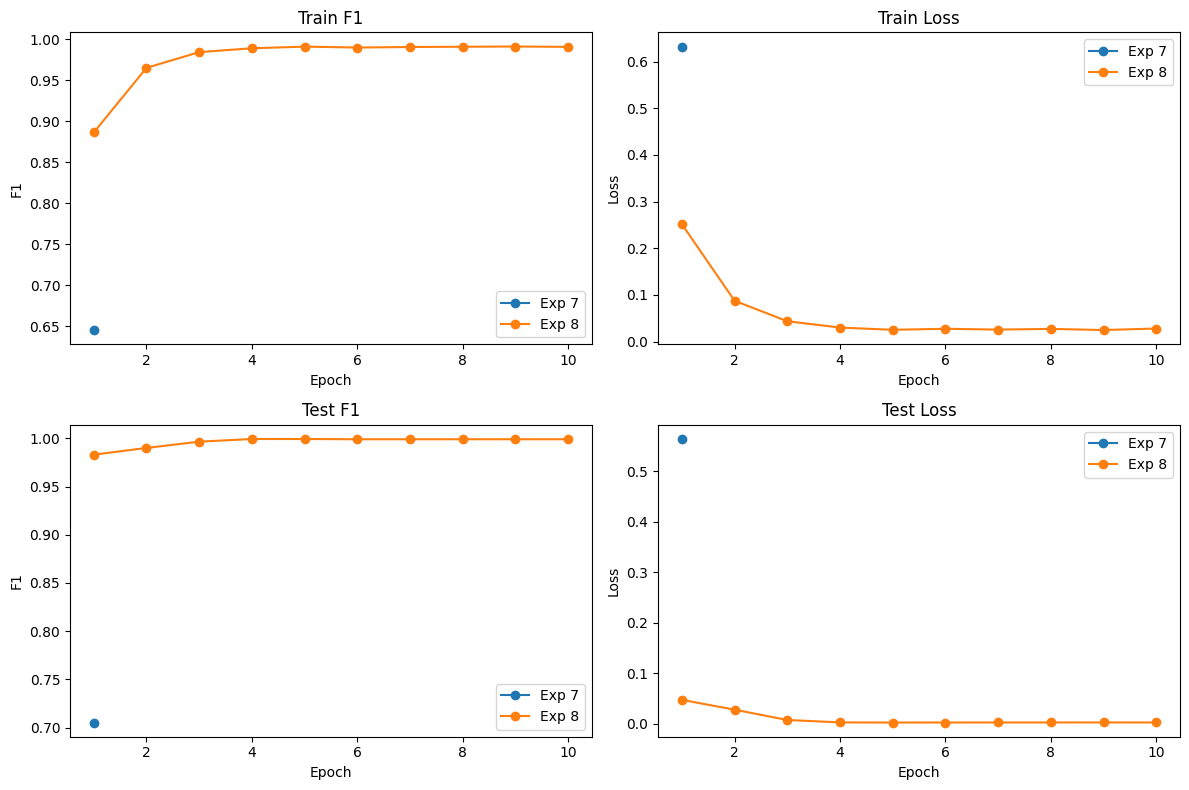

In [6]:
# ============================================
# DeepFake Face Detection — Full Colab Version (Updated)
# ConvNeXt-Tiny & ViT-B/16, with Augmentations
# Includes optimizer/head-params fix for no-FT path
# ============================================

import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchvision.models.vision_transformer import vit_b_16, ViT_B_16_Weights
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt

# ----------------------------
# 0) Paths & device
# ----------------------------
# If DATA_ROOT already defined, we keep it. Else try to auto-detect.
if 'DATA_ROOT' not in globals():
    guess = "/content/data/real_vs_fake/real-vs-fake"
    if os.path.isdir(guess) and os.path.isdir(os.path.join(guess, "train")) and os.path.isdir(os.path.join(guess, "test")):
        DATA_ROOT = guess
    else:
        raise RuntimeError(
            "DATA_ROOT is not set and auto-detect failed.\n"
            "Set DATA_ROOT (string) to the folder that contains 'train/' and 'test/'."
        )

print("Using DATA_ROOT:", DATA_ROOT)
assert os.path.isdir(os.path.join(DATA_ROOT, "train")), f"Missing train/ at {DATA_ROOT}"
assert os.path.isdir(os.path.join(DATA_ROOT, "test")),  f"Missing test/ at {DATA_ROOT}"

SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())

# ----------------------------
# 1) Model builders
# ----------------------------
def build_convnext_tiny(num_classes=2):
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    in_feats = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_feats, num_classes)
    return model

def build_vit_b16(num_classes=2):
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    model.heads = nn.Linear(768, num_classes)
    return model

# ----------------------------
# 2) Transforms
# ----------------------------
def base_transform(model_type: str):
    if model_type == 'convnext':
        return transforms.Compose([
            transforms.Resize(224), transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
        ])
    elif model_type == 'vit':
        return ViT_B_16_Weights.IMAGENET1K_V1.transforms()
    else:
        raise ValueError("model_type must be 'convnext' or 'vit'")

def autoaugment_transform(model_type: str):
    return transforms.Compose([
        transforms.Resize(224), transforms.CenterCrop(224),
        transforms.AutoAugment(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

def randaugment_transform(model_type: str):
    return transforms.Compose([
        transforms.Resize(224), transforms.CenterCrop(224),
        transforms.RandAugment(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

def auto_rand_augment_transform(model_type: str):
    return transforms.Compose([
        transforms.Resize(224), transforms.CenterCrop(224),
        transforms.AutoAugment(),
        transforms.RandAugment(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

# ----------------------------
# 3) Data loaders
# ----------------------------
def full_data_transform(model_type, data_fraction, batch_size):
    tfm = base_transform(model_type)
    full_train = ImageFolder(os.path.join(DATA_ROOT, "train"), transform=tfm)
    full_test  = ImageFolder(os.path.join(DATA_ROOT, "test"),  transform=tfm)

    # Sample a fraction (by length)
    n_tr = max(1, int(len(full_train) * data_fraction))
    n_te = max(1, int(len(full_test)  * data_fraction))

    tr_idx = random.sample(range(len(full_train)), n_tr)
    te_idx = random.sample(range(len(full_test)),  n_te)
    train_ds = Subset(full_train, tr_idx)
    test_ds  = Subset(full_test,  te_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=max(1,batch_size//2), shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader, tr_idx, te_idx

def ft_test_loader(model_type, data_fraction, batch_size):
    tfm = base_transform(model_type)
    full_test  = ImageFolder(os.path.join(DATA_ROOT, "test"),  transform=tfm)
    n_te = max(1, int(len(full_test) * data_fraction))
    te_idx = random.sample(range(len(full_test)), n_te)
    test_ds = Subset(full_test, te_idx)
    test_loader  = DataLoader(test_ds, batch_size=max(1,batch_size//2), shuffle=False, num_workers=2, pin_memory=True)
    return test_loader

def augmented_train_loader(model_type, which_aug: str, train_indices, batch_size):
    if which_aug == 'auto':
        aug_tfm = autoaugment_transform(model_type)
    elif which_aug == 'rand':
        aug_tfm = randaugment_transform(model_type)
    elif which_aug == 'both':
        aug_tfm = auto_rand_augment_transform(model_type)
    else:
        raise ValueError("which_aug must be 'auto' | 'rand' | 'both'")

    full_train_aug = ImageFolder(os.path.join(DATA_ROOT, "train"), transform=aug_tfm)
    train_ds = Subset(full_train_aug, train_indices)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    return train_loader

# ----------------------------
# 4) Train & test
# ----------------------------
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    y_true, y_pred = [], []

    loop = tqdm(dataloader, total=len(dataloader))
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        y_true.extend(labels.detach().cpu().tolist())
        y_pred.extend(predicted.detach().cpu().tolist())
        loop.set_description("Train")
        loop.set_postfix(loss=loss.item())

    loss_avg = running_loss / max(1, len(dataloader))
    acc = accuracy_score(y_true, y_pred)
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    print(f"Train Loss: {loss_avg:.6f} | Train Acc: {acc*100:.2f}% | Train F1: {f1:.6f}")
    return loss_avg, acc, f1

def eval_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            y_true.extend(labels.detach().cpu().tolist())
            y_pred.extend(predicted.detach().cpu().tolist())

    loss_avg = running_loss / max(1, len(dataloader))
    acc = accuracy_score(y_true, y_pred)
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    print(f"Test  Loss: {loss_avg:.6f} | Test  Acc: {acc*100:.2f}% | Test  F1: {f1:.6f}")
    return loss_avg, acc, f1

def train_model(model_type, exp, model, train_loader, test_loader, criterion, optimizer, scheduler,
                device, num_epochs, fine_tune_flag, num_tag, df):
    model = model.to(device)

    for epoch in range(num_epochs):
        print('-------------------------------------------------------------')
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        te_loss, te_acc, te_f1 = eval_model(model, test_loader, criterion, device)

        # Save metrics row
        df.loc[len(df)] = [model_type, exp, epoch+1, tr_acc, tr_loss, tr_f1, te_acc, te_loss, te_f1]
        df.to_csv('/content/metricas.csv', index=False)

        # Step LR
        if scheduler:
            scheduler.step()

        # Save model checkpoint
        model_name = f"model_{model_type}_exp_{exp}_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), os.path.join('/content', model_name))
        print(f"Saved: /content/{model_name}\n")

    return tr_loss, tr_acc, tr_f1, te_loss, te_acc, te_f1, df

# ----------------------------
# 5) Experiment runner (scenarios 1..5)
# ----------------------------
def run_scenario(model_type, scenario, data_fraction, num_epochs=50, batch_size=32, learning_rate=1e-4, df=None):
    """
    Scenarios:
      1: No Fine-Tuning, No Aug
      2: Fine-Tuning, No Aug
      3: AutoAugment -> (No FT, then FT)
      4: RandAugment -> (No FT, then FT)
      5: Auto+Rand   -> (No FT, then FT)
    """
    assert model_type in ('convnext', 'vit')
    if df is None:
        # FIX: column names consistent with rest of code
        df = pd.DataFrame(columns=[
            'Model','Experiment','Epoch',
            'Train ACC','Train Loss','Train F1',
            'Test ACC','Test Loss','Test F1'
        ])

    # loaders for the base (non-aug) case
    base_train_loader, base_test_loader, train_idx, test_idx = full_data_transform(model_type, data_fraction, batch_size)

    # ---- helper: materialize head params as list so optimizer isn't empty ----
    def build_model_and_optim(ft: bool):
        if model_type == 'convnext':
            model = build_convnext_tiny(num_classes=2)
            head_module = model.classifier[-1]
        else:
            model = build_vit_b16(num_classes=2)
            head_module = model.heads

        head_params = list(head_module.parameters())  # IMPORTANT: list(), not generator

        if ft:
            # Fine-tune: train all params
            for p in model.parameters():
                p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
        else:
            # Feature-extract: freeze backbone, train only head
            for p in model.parameters():
                p.requires_grad = False
            for p in head_params:
                p.requires_grad = True
            optimizer = optim.AdamW(head_params, lr=learning_rate)

        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
        return model, optimizer, scheduler

    criterion = nn.CrossEntropyLoss()

    # Scenario 1: No FT, no aug (1 epoch)
    if scenario == 1:
        model, optimizer, scheduler = build_model_and_optim(ft=False)
        print(f"Experimento 1 - {model_type.upper()} (Sem Fine-Tuning)")
        _ = train_model(model_type, 1, model, base_train_loader, base_test_loader,
                        criterion, optimizer, scheduler, device, num_epochs=1, fine_tune_flag=False, num_tag=1, df=df)

    # Scenario 2: FT, no aug
    elif scenario == 2:
        model, optimizer, scheduler = build_model_and_optim(ft=True)
        print(f"Experimento 2 - {model_type.upper()} (Com Fine-Tuning)")
        _ = train_model(model_type, 2, model, base_train_loader, base_test_loader,
                        criterion, optimizer, scheduler, device, num_epochs=num_epochs, fine_tune_flag=True, num_tag=2, df=df)

    # Scenario 3: AutoAug (No FT -> 1 epoch; FT -> num_epochs)
    elif scenario == 3:
        aug_train_loader = augmented_train_loader(model_type, 'auto', train_idx, batch_size)
        test_loader = ft_test_loader(model_type, data_fraction, batch_size)

        model, optimizer, scheduler = build_model_and_optim(ft=False)
        print(f"Experimento 3 - {model_type.upper()} (Sem Fine-Tuning e com AutoAugment)")
        _ = train_model(model_type, 3, model, aug_train_loader, test_loader,
                        criterion, optimizer, scheduler, device, num_epochs=1, fine_tune_flag=False, num_tag=3, df=df)

        model, optimizer, scheduler = build_model_and_optim(ft=True)
        print(f"Experimento 4 - {model_type.upper()} (Com Fine-Tuning e com AutoAugment)")
        _ = train_model(model_type, 4, model, aug_train_loader, test_loader,
                        criterion, optimizer, scheduler, device, num_epochs=num_epochs, fine_tune_flag=True, num_tag=4, df=df)

    # Scenario 4: RandAug (No FT -> 1 epoch; FT -> num_epochs)
    elif scenario == 4:
        aug_train_loader = augmented_train_loader(model_type, 'rand', train_idx, batch_size)
        test_loader = ft_test_loader(model_type, data_fraction, batch_size)

        model, optimizer, scheduler = build_model_and_optim(ft=False)
        print(f"Experimento 5 - {model_type.upper()} (Sem Fine-Tuning e com RandAugment)")
        _ = train_model(model_type, 5, model, aug_train_loader, test_loader,
                        criterion, optimizer, scheduler, device, num_epochs=1, fine_tune_flag=False, num_tag=5, df=df)

        model, optimizer, scheduler = build_model_and_optim(ft=True)
        print(f"Experimento 6 - {model_type.upper()} (Com Fine-Tuning e com RandAugment)")
        _ = train_model(model_type, 6, model, aug_train_loader, test_loader,
                        criterion, optimizer, scheduler, device, num_epochs=num_epochs, fine_tune_flag=True, num_tag=6, df=df)

    # Scenario 5: Auto + Rand (No FT -> 1 epoch; FT -> num_epochs)
    elif scenario == 5:
        aug_train_loader = augmented_train_loader(model_type, 'both', train_idx, batch_size)
        test_loader = ft_test_loader(model_type, data_fraction, batch_size)

        model, optimizer, scheduler = build_model_and_optim(ft=False)
        print(f"Experimento 7 - {model_type.upper()} (Sem Fine-Tuning e com AutoAugment e RandAugment)")
        _ = train_model(model_type, 7, model, aug_train_loader, test_loader,
                        criterion, optimizer, scheduler, device, num_epochs=1, fine_tune_flag=False, num_tag=7, df=df)

        model, optimizer, scheduler = build_model_and_optim(ft=True)
        print(f"Experimento 8 - {model_type.upper()} (Com Fine-Tuning e com AutoAugment e RandAugment)")
        _ = train_model(model_type, 8, model, aug_train_loader, test_loader,
                        criterion, optimizer, scheduler, device, num_epochs=num_epochs, fine_tune_flag=True, num_tag=8, df=df)

    else:
        raise ValueError("scenario must be in {1,2,3,4,5}")

    return df

# ----------------------------
# 6) Plotting helpers
# ----------------------------
def plot_experiment_graphs(df, experiment_number):
    # FIX: use 'Experiment' column (English name)
    exp_df = df[df['Experiment'] == experiment_number]
    if exp_df.empty:
        print(f"No rows for experiment {experiment_number}")
        return

    plt.figure(figsize=(7,5))
    plt.plot(exp_df['Epoch'], exp_df['Train F1'], marker='o')
    plt.xlabel('Epoch'); plt.ylabel('Train F1'); plt.title(f'Experimento {experiment_number} - Train F1')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(exp_df['Epoch'], exp_df['Train ACC'], marker='o')
    plt.xlabel('Epoch'); plt.ylabel('Train Accuracy'); plt.title(f'Experimento {experiment_number} - Train ACC')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(exp_df['Epoch'], exp_df['Train Loss'], marker='o')
    plt.xlabel('Epoch'); plt.ylabel('Train Loss'); plt.title(f'Experimento {experiment_number} - Train Loss')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(exp_df['Epoch'], exp_df['Test F1'], marker='o')
    plt.xlabel('Epoch'); plt.ylabel('Test F1'); plt.title(f'Experimento {experiment_number} - Test F1')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(exp_df['Epoch'], exp_df['Test ACC'], marker='o')
    plt.xlabel('Epoch'); plt.ylabel('Test Accuracy'); plt.title(f'Experimento {experiment_number} - Test ACC')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(exp_df['Epoch'], exp_df['Test Loss'], marker='o')
    plt.xlabel('Epoch'); plt.ylabel('Test Loss'); plt.title(f'Experimento {experiment_number} - Test Loss')
    plt.tight_layout(); plt.show()

def plot_general_graphs(df):
    if df.empty:
        print("DataFrame is empty — nothing to plot.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    # FIX: iterate over 'Experiment' column
    for exp in sorted(df['Experiment'].unique()):
        exp_df = df[df['Experiment'] == exp]
        axes[0,0].plot(exp_df['Epoch'], exp_df['Train F1'], marker='o', label=f'Exp {exp}')
        axes[0,1].plot(exp_df['Epoch'], exp_df['Train Loss'], marker='o', label=f'Exp {exp}')
        axes[1,0].plot(exp_df['Epoch'], exp_df['Test F1'], marker='o', label=f'Exp {exp}')
        axes[1,1].plot(exp_df['Epoch'], exp_df['Test Loss'], marker='o', label=f'Exp {exp}')

    axes[0,0].set_title('Train F1');   axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('F1'); axes[0,0].legend()
    axes[0,1].set_title('Train Loss'); axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss'); axes[0,1].legend()
    axes[1,0].set_title('Test F1');    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('F1'); axes[1,0].legend()
    axes[1,1].set_title('Test Loss');  axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss'); axes[1,1].legend()
    plt.tight_layout(); plt.show()

# ----------------------------
# 7) Example runs (start small)
# ----------------------------
df_metrics = pd.DataFrame(columns=[
    'Model','Experiment','Epoch',
    'Train ACC','Train Loss','Train F1',
    'Test ACC','Test Loss','Test F1'
])

# Example: ConvNeXt, scenario 5 (Auto+Rand, FT)
df_metrics = run_scenario(
    'convnext',
    scenario=5,
    data_fraction=0.2,
    num_epochs=10,
    batch_size=64,
    learning_rate=1e-4,
    df=df_metrics
)

print("\nMetrics head:")
print(df_metrics.head())
print("\nMetrics tail:")
print(df_metrics.tail())

# (Optional) plot helpers:
plot_experiment_graphs(df_metrics, experiment_number=2)  # or 7/8 depending what you want
plot_general_graphs(df_metrics)



In [ ]:
# STEP 6 — Fully functional upload app (Gradio)

!pip install gradio -q

import gradio as gr
import torch.nn.functional as F

# Use the same idx_to_class and inference_transform defined earlier

import numpy as np

import torch.nn.functional as F
import numpy as np

def classify_image(img):
    # Convert to RGB
    img = img.convert("RGB")
    # Preprocess
    x = inference_transform(img).unsqueeze(0).to(device)

    # Model forward
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    p_fake, p_real = float(probs[0]), float(probs[1])

    # ----- THRESHOLD LOGIC -----
    high_thresh = 0.70

    if p_fake > high_thresh and p_fake > p_real:
        decided_label = "FAKE"
    elif p_real > high_thresh and p_real > p_fake:
        decided_label = "REAL"
    else:
        decided_label = "UNCERTAIN"

    # PRINT to notebook / Colab logs (NOT part of the Gradio output)
    print("--------------------------------------")
    print("Model probabilities:")
    print(f"  Fake: {p_fake:.4f}")
    print(f"  Real: {p_real:.4f}")
    print("Decision:", decided_label)
    print("--------------------------------------")

    # ---- RETURN ONLY FLOATS FOR GRADIO ----
    return {
        "fake": p_fake,
        "real": p_real,
    }

demo = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="Real vs Fake Face Detector (ConvNeXt + Sora Finetune)",
    description="Upload a face. The model predicts whether it is FAKE or REAL."
)

demo.launch(debug=True)




It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1480a0b359d070f3fd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

--------------------------------------
Model probabilities:
  Fake: 0.6712
  Real: 0.3288
Decision: UNCERTAIN
--------------------------------------


In [25]:
print("SORA TRAIN PATHS:", sora_train_paths[:15])
print("SORA VAL PATHS:", sora_val_paths[:15])
print("COUNT TRAIN:", len(sora_train_paths))
print("COUNT VAL:", len(sora_val_paths))


SORA TRAIN PATHS: ['/content/sora_faces_224/White Demographic Group/WhitePerson54.png', '/content/sora_faces_224/Black Demographic Group/BlackPerson17.png', '/content/sora_faces_224/White Demographic Group/WhitePerson11.png', '/content/sora_faces_224/Black Demographic Group/BlackPerson13.png', '/content/sora_faces_224/White Demographic Group/WhitePerson20.png', '/content/sora_faces_224/Black Demographic Group/BlackPerson14.png', '/content/sora_faces_224/White Demographic Group/WhitePerson17.png', '/content/sora_faces_224/White Demographic Group/WhitePerson38.png', '/content/sora_faces_224/Asian Demographic Group/AsianPerson5.png', '/content/sora_faces_224/White Demographic Group/WhitePerson41.png', '/content/sora_faces_224/White Demographic Group/WhitePerson18.png', '/content/sora_faces_224/Asian Demographic Group/AsianPerson8.png', '/content/sora_faces_224/Black Demographic Group/BlackPerson24.png', '/content/sora_faces_224/Asian Demographic Group/AsianPerson2.png', '/content/sora_fac